In [379]:
import otter
grader = otter.Notebook()

In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# DSCI 311 Fall 25 Midterm
## Due Date: Thursday 10/30 by 11:59 PM PST

**Collaboration Policy: No collaboration is allowed on this test. All work must be your own.**

**AI Policy**: You may use AI (and other internet resources) to *help* you answer questions. You may not copy any code wholesale from AI output. Consider AI as an informative assistant, *not* as a replacement for you (on this exam and in life). If I suspect purely AI-generated code, I'll ask you about it and expect you to explain clearly why you coded things in that way.

- An appropriate AI query: "I need to make this dataset longer but can't figure out the argument for turning columns into values. Can you help me understand the function?"

- An invalid AI query: "Give me code to make these data longer."

**Note that for ALL plotting questions, we will expect appropriate titles, axis labels, legends, etc. The following question serves as a good guideline on what is "enough": If I directly downloaded the plot and viewed it, would I be able to tell what was being visualized without knowing the question?** 

This midterm may cover any topics through the first 4 weeks of class. You may be expected to do things that we have not explicitly shown in class or in an assignment - this is intentional, and why we expect you to reference function documentation (*e.g.* `help(pd.read_csv)`) or internet resources for help. But most of what you will do will have been shown either in lecture (in slides or in lecture notebooks) or in assignments. 

There are three sections to the midterm:

**Section 1**: Candy 

**Section 2**: Horror movies

**Section 3**: Hauntings

**Grader Tests**: As in homeworks, these tests only check whether your answer *could* be correct, not whether it is correct. 

## Section 1

Here we'll be reading in two datasets describing halloween candy - `candy_qualities.csv`, which contains traits associated with various halloween candies, and `candy_rankings.csv` which contains ranked preferences for each candy and a few additional characteristics as surveyed in 2017 with 269,000 votes. Our objective is simple: **determine the ultimate halloween candies and their characteristics**. The first step in this process will be to combine our data.

`candy_qualities.csv`:
    
    `name` - the name of the candy
    `quality` - some quality that may or may not represent the candy
    `value` - whether or not candy has the associated quality 

    Note that the quality 'pluribus' means candy that comes in multiples (think Skittles)
    
`candy_rankings.csv`: 

    `competitorname` - the name of the candy
    `sugarpercent` - the percentile of sugar it falls under in the data set
    `pricepercent` - the unit price percentile compared to the rest of the data set
    `winpercent` - the overall win percentage based on 269,000 matchups. 

Read in `candy_qualities.csv` and `candy_rankings.csv`.

In [381]:
candy_quals = pd.read_csv("data/candy_qualities.csv")

In [382]:
candy_quals.head()

,name,quality,value
0,100 Grand,chocolate,1
1,3 Musketeers,chocolate,1
2,One dime,chocolate,0
3,One quarter,chocolate,0
4,Air Heads,chocolate,0


In [383]:
candy_rankings = pd.read_csv("data/candy_rankings.csv")

In [384]:
candy_rankings.head()

,competitorname,sugarpercent,pricepercent,winpercent
0,100 Grand,0.732,0.860,66.971725
1,3 Musketeers,0.604,0.511,67.602936
2,One dime,0.011,0.116,32.261086
3,One quarter,0.011,0.511,46.116505
4,Air Heads,0.906,0.511,52.341465


#### Question 1

Our goal is to merge our two datasets together without duplicating any records. We therefore need to first format our datasets similarily. Pivot `candy_quals` so that there is only a **single record** (row) per candy. In other words, the granularity of the data should be at the level of candy name.

In [385]:
candy_wide = candy_quals.pivot(index='name', columns='quality', values='value').reset_index()
candy_wide

quality,name,bar,caramel,chocolate,crispedricewafer,fruity,hard,nougat,peanutyalmondy,pluribus
0,100 Grand,1,1,1,1,0,0,0,0,0
1,3 Musketeers,1,0,1,0,0,0,1,0,0
2,Air Heads,0,0,0,0,1,0,0,0,0
3,Almond Joy,1,0,1,0,0,0,0,1,0
4,Baby Ruth,1,1,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,0,0,0,1,0,0,0,0
81,Warheads,0,0,0,0,1,1,0,0,0
82,WelchÕs Fruit Snacks,0,0,0,0,1,0,0,0,1
83,WertherÕs Original Caramel,0,1,0,0,0,1,0,0,0


In [386]:
grader.check("q1_1")

q1_1 results: All test cases passed!

#### Question 2

To combine our two datasets, we need to canonicalize their keys. Identify all of the candy names in `candy_wide` that aren't matches in `candy_rankings`, returned as a Series or a numpy array.

In [387]:
ranking_names = candy_rankings['competitorname'].to_numpy()
comparison = candy_wide['name'].isin(ranking_names)
mismatches = candy_wide.loc[comparison == False, 'name'].to_numpy()
mismatches

array(['HersheyÕs Kisses', 'HersheyÕs Krackel',
       'HersheyÕs Milk Chocolate', 'HersheyÕs Special Dark', 'M&MÕs',
       'Peanut butter M&MÕs', 'ReeseÕs Miniatures',
       'ReeseÕs Peanut Butter cup', 'ReeseÕs pieces',
       'ReeseÕs stuffed with pieces', 'WelchÕs Fruit Snacks',
       'WertherÕs Original Caramel'], dtype=object)

In [388]:
grader.check("q1_2")

q1_2 results: All test cases passed!

#### Question 3

Fix the issues in the key of `candy_wide` so that we can successfully merge our data (*i.e.* make these non-matching values match their counterparts in `candy_rankings`). 

In [389]:
candy_wide['name'] = candy_wide['name'].str.replace("Õ", "")
candy_wide

quality,name,bar,caramel,chocolate,crispedricewafer,fruity,hard,nougat,peanutyalmondy,pluribus
0,100 Grand,1,1,1,1,0,0,0,0,0
1,3 Musketeers,1,0,1,0,0,0,1,0,0
2,Air Heads,0,0,0,0,1,0,0,0,0
3,Almond Joy,1,0,1,0,0,0,0,1,0
4,Baby Ruth,1,1,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,0,0,0,1,0,0,0,0
81,Warheads,0,0,0,0,1,1,0,0,0
82,Welchs Fruit Snacks,0,0,0,0,1,0,0,0,1
83,Werthers Original Caramel,0,1,0,0,0,1,0,0,0


In [390]:
grader.check("q1_3")

q1_3 results: All test cases passed!

#### Question 4

Finally, merge the two Dataframes such that no information is lost in either frame. 

In [391]:
candy = pd.merge(candy_rankings, candy_wide, how = 'outer', left_on = 'competitorname', right_on = 'name')
candy

,competitorname,sugarpercent,pricepercent,winpercent,name,bar,caramel,chocolate,crispedricewafer,fruity,hard,nougat,peanutyalmondy,pluribus
0,100 Grand,0.732,0.860,66.971725,100 Grand,1,1,1,1,0,0,0,0,0
1,3 Musketeers,0.604,0.511,67.602936,3 Musketeers,1,0,1,0,0,0,1,0,0
2,Air Heads,0.906,0.511,52.341465,Air Heads,0,0,0,0,1,0,0,0,0
3,Almond Joy,0.465,0.767,50.347546,Almond Joy,1,0,1,0,0,0,0,1,0
4,Baby Ruth,0.604,0.767,56.914547,Baby Ruth,1,1,1,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0.220,0.116,45.466282,Twizzlers,0,0,0,0,1,0,0,0,0
81,Warheads,0.093,0.116,39.011898,Warheads,0,0,0,0,1,1,0,0,0
82,Welchs Fruit Snacks,0.313,0.313,44.375519,Welchs Fruit Snacks,0,0,0,0,1,0,0,0,1
83,Werthers Original Caramel,0.186,0.267,41.904308,Werthers Original Caramel,0,1,0,0,0,1,0,0,0


In [392]:
grader.check("q1_4")

q1_4 results: All test cases passed!

#### Question 5

Plot the associations with regression lines between sugar % and win %, and price % and win %. Plot both associations on the same figure and ensure that each has a different color. Include a legend labeling each color. 

You can use any method you want for the regression lines, either estimating them manually or using seaborn's plotting functions. 

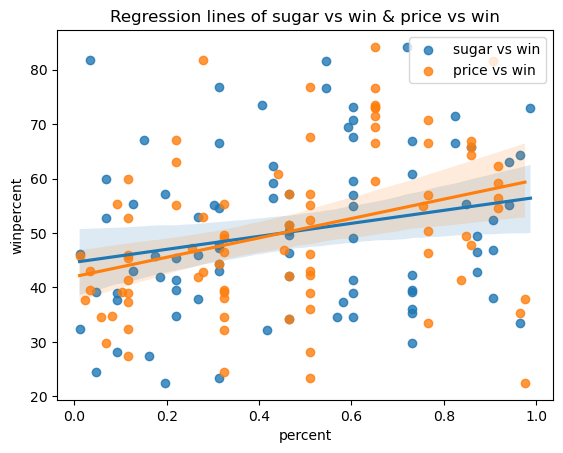

In [393]:
sns.regplot(candy, x = 'sugarpercent', y = 'winpercent', fit_reg = True, label = 'sugar vs win')
sns.regplot(candy, x = 'pricepercent', y = 'winpercent', fit_reg = True, label = 'price vs win')
plt.title('Regression lines of sugar vs win & price vs win')
plt.legend()
plt.xlabel('percent')
plt.show()

#### Question 6

What can we infer about more popular candy from the above plot?

**Your response**: We can infer a positive correlation between candy popularity and price from the above plot. As a candy increases in winpercent the pricepercent also increases. For the more popular candy it is generally sweeter as seen on the plot above where the regression line is positive. The relationships however, are not that strong

#### Question 7

Create a **horizontal** barplot representing the sums of each candy quality. Ensure the barplot is sorted from most to least.  

<Axes: title={'center': 'Sum of each Candy Quality'}, xlabel='tot_score', ylabel='quality_type'>

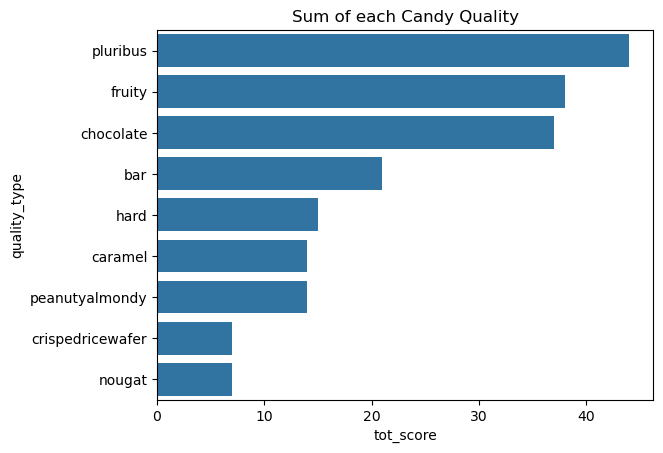

In [394]:
quality_sum = candy[['bar', 'caramel', 'chocolate', 'crispedricewafer', 
                              'fruity', 'hard', 'nougat', 'peanutyalmondy', 
                              'pluribus']].sum()
qual_sum_df = quality_sum.reset_index()
qual_sum_df.columns = ['quality_type', 'tot_score']
qual_sum_df_sorted =  qual_sum_df.sort_values(by = 'tot_score', ascending = False)
plt.title('Sum of each Candy Quality')
sns.barplot(qual_sum_df_sorted, x = 'tot_score', y = 'quality_type')



#### Question 8

Now split the data into two subsets: the 50% of candy above the median of win percent and the 50% of candy below the median. Then plot a **paired**, horizontal barplot representing the same counts of each quality as above, where black bars represent the less popular candy and orange bars represent the more popular candy. 

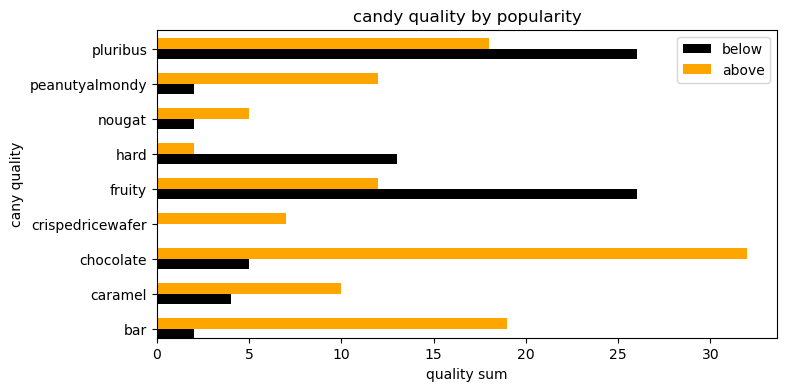

In [395]:
median = candy["winpercent"].median()

below = candy[candy["winpercent"] < median]
above = candy[candy["winpercent"] >= median]
quality_col = candy.columns.difference(["winpercent", "sugarpercent", "pricepercent", "name", "competitorname"])
below_sums = below[quality_col].sum()
above_sums = above[quality_col].sum()
fig, ax = plt.subplots(figsize=(8, 4))

below_sums.plot(kind="barh", color="black", ax=ax, position=1, width=0.3, label="below")

above_sums.plot(kind="barh", color="orange", ax=ax, position=0, width=0.3, label="above")

plt.title("candy quality by popularity")
plt.xlabel("quality sum")
plt.ylabel("cany quality")
plt.legend()


#### Question 9

Characterize the most popular and the least popular halloween candy, giving extra emphasis to how they differ.

**Your response**: The analysis reveals a significant disparity in candy popularity. The three most popular qualities were chocolate, bar, and pluribus. In contrast, the three least popular were crispedricewafer, peanut almond, and nougat. The crispedricewafer quality scored well below the median, which could suggest that very few candies with this attribute were purchased. A strong correlation exists between popularity and quality: the most popular candy types had a much higher average quality than the least popular. This suggests that the high-quality, popular items may have sold out, leaving less desirable options behind.

## Section 2

Read in the `IMDB Horror Movies` dataset. This dataset represents a subset of some of the best-know movies in the horror genre released between 1920 and 2023.  

In [396]:
horror = pd.read_csv("./data/Horror Movies IMDB.csv")
horror.head()

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M
4,Tumbbad,2018,104,"Drama, Fantasy, Horror",8.2,Rahi Anil Barve,"53,297",NaN


#### Question 1

`Gross` represents the total amount each movie grossed in theatres in millions.

What type of variable does `Gross` represent? Based on your answer, what issues are there in the current formatting of the variable? 

**Your response**: Gross is a quantitative and a continuous variable, but is an string object, not an integer within the dataset. This would cause errors if we try to preform any analysis, meaning we need to convert it to move formward.

#### Question 2

Clean a variable `Gross_clean` such that it is now the type of variable you identified above and can be used for analyses. We don't want to look at movies that didn't make any money, so also filter the data for values of `Gross_clean` greater than 0. 

In [397]:
horror['Gross_clean'] = horror['Gross'].str.replace('$', '').str.replace('M', '').astype(float) * 1000000
horror = horror.query('Gross_clean > 0')
horror

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross,Gross_clean
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M,78900000.0
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M,32000000.0
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M,44020000.0
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M,13780000.0
5,The Exorcist,1973,122,Horror,8.1,William Friedkin,"4,22,330",$232.91M,232910000.0
...,...,...,...,...,...,...,...,...,...
828,Slender Man I,2018,93,"Horror, Mystery, Thriller",3.2,Sylvain White,"36,238",$30.57M,30570000.0
829,Jaws: The Revenge,1987,89,"Adventure, Horror, Thriller",3.0,Joseph Sargent,"47,708",$20.76M,20760000.0
830,BloodRayne,2005,95,"Action, Fantasy, Horror",3.0,Uwe Boll,"36,527",$2.41M,2410000.0
833,Alone in the Dark,2005,96,"Action, Horror, Sci-Fi",2.4,Uwe Boll,"46,403",$5.18M,5180000.0


In [398]:
grader.check("q2_2")

q2_2 results: All test cases passed!

#### Question 3

First create a subset of the data filtering out NA values in `Gross_clean`. 

Then visualize the distributions of `Gross_clean` and `Rating`. Apply any tansformations to the data (if necessary) to make both variables approximately normally distributed. It's fine if there is still some tail to the distribution.

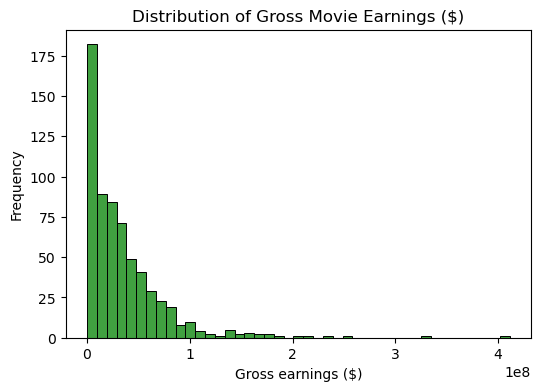

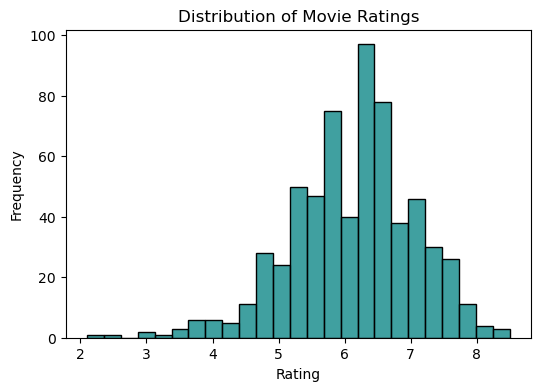

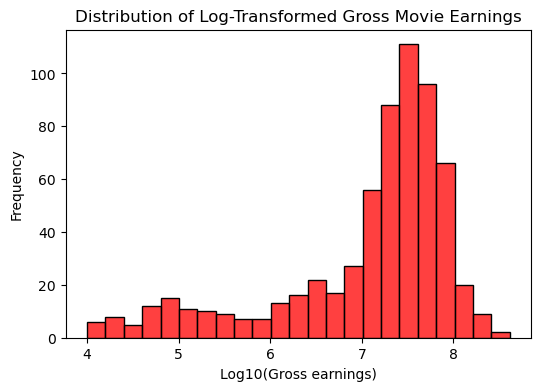

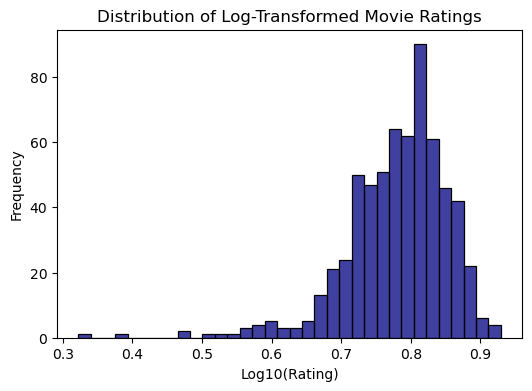

In [399]:
#earnings
plt.figure(figsize=(6,4))
sns.histplot(horror['Gross_clean'], color='green')
plt.xlabel('Gross earnings ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Gross Movie Earnings ($)')
plt.show()

#rating
plt.figure(figsize=(6,4))
sns.histplot(horror['Rating'], color='teal')
plt.ylabel('Frequency')
plt.title('Distribution of Movie Ratings')
plt.show()

# Log transform each and replot

plt.figure(figsize=(6,4))
sns.histplot(np.log10(horror['Gross_clean']), color='red')
plt.xlabel('Log10(Gross earnings)')
plt.ylabel('Frequency')
plt.title('Distribution of Log-Transformed Gross Movie Earnings')
plt.show()

# Plot transformed rating
plt.figure(figsize=(6,4))
sns.histplot(np.log10(horror['Rating']), color='navy')
plt.ylabel('Frequency')
plt.xlabel('Log10(Rating)')
plt.title('Distribution of Log-Transformed Movie Ratings')
plt.show()

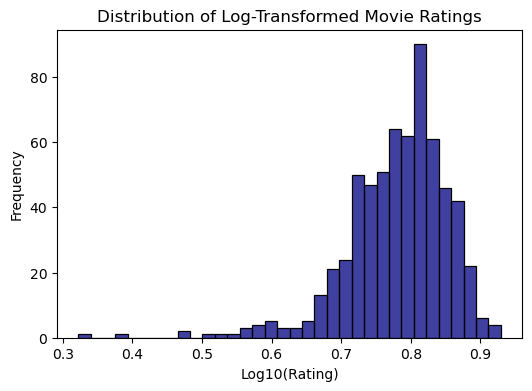

In [400]:
plt.figure(figsize=(6,4))
sns.histplot(np.log10(horror['Rating']), color='navy')
plt.ylabel('Frequency')
plt.xlabel('Log10(Rating)')
plt.title('Distribution of Log-Transformed Movie Ratings')
plt.show()

#### Question 4

One of the presumed characteristics of "oscar bait" i.e. films gunning for awards is a long runtime. Is there any evidence for this among horror movies? Evaluate this visually with a regression plot for each of the transformed and untransformed rating. 

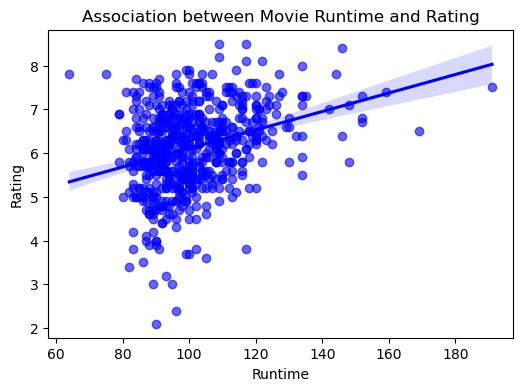

In [401]:
# Untransformed regression
plt.figure(figsize=(6,4))
sns.regplot(y=horror['Rating'], x=horror['Runtime'], color='Blue', scatter_kws={'alpha':0.6})

plt.title('Association between Movie Runtime and Rating')
plt.show()

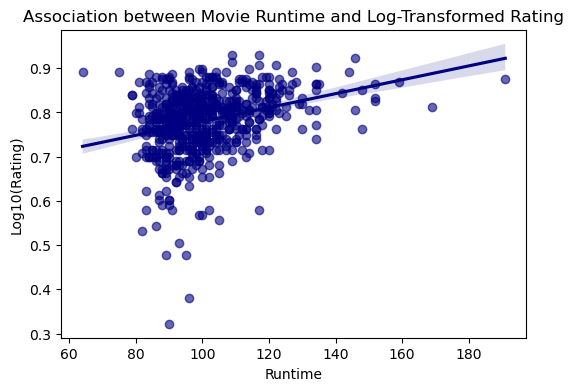

In [402]:
# Transformed regression
plt.figure(figsize=(6,4))
sns.regplot(y=np.log10(horror['Rating']),
            x=horror['Runtime'],
            color='navy',
            scatter_kws={'alpha':0.6})

plt.ylabel('Log10(Rating)')
plt.title('Association between Movie Runtime and Log-Transformed Rating')
plt.show()

#### Question 5

What do you conclude from the above visualization? Describe the association, and whether you think a simple linear model is an effective description of the relationship.

**Your response** : While the visualizations hint at a weak, positive correlation between film length and rating, this effect is minimal. Furthermore, the presence of clustering and nonlinear trends in the data indicates that a simple linear model is not an effective way to describe this relationship.

#### Question 6

Who are the 5 most highly rated directors (on average) **among directors with at least 3 movies in the data**? Return your answer as a Series or numpy array.

In [403]:
director_counts = horror['Director'].value_counts()
eligible_directors = director_counts[director_counts >= 3].index
director_avg_rating = (horror[horror['Director'].isin(eligible_directors)].groupby('Director')['Rating'].mean().sort_values(ascending=False))

best_directors = director_avg_rating.iloc[:5]
best_directors

Director
Jordan Peele        7.133333
David Cronenberg    7.116667
Sam Raimi           7.116667
Robert Rodriguez    7.100000
James Wan           6.966667
Name: Rating, dtype: float64

In [404]:
grader.check("q2_6")

q2_6 results: All test cases passed!

#### Question 8

Create three new columns in `horror` called `Primary Genre`, `Secondary Genre` and `Tertiary Genre`. These columns should be populated by the values in Genre in the order they appear. For example, the movie Alien should have "Horror" as its primary genre, "Sci-Fi" as its secondary genre, and "None" as its tertiary genre.

*Hint* You may want to review your string methods here.

In [405]:
horror[['Primary Genre', 'Secondary Genre', 'Tertiary Genre']] = horror['Genre'].str.split(', ', expand=True)
horror.head()

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross,Gross_clean,Primary Genre,Secondary Genre,Tertiary Genre
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M,78900000.0,Horror,Sci-Fi,None
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M,32000000.0,Horror,Mystery,Thriller
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M,44020000.0,Drama,Horror,None
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M,13780000.0,Horror,Mystery,Sci-Fi
5,The Exorcist,1973,122,Horror,8.1,William Friedkin,"4,22,330",$232.91M,232910000.0,Horror,None,None


In [406]:
grader.check("q2_8")

q2_8 results: All test cases passed!

#### Question 9

All of the movies in the dataset are horror movies, so the inclusion of Horror as a genre isn't helpful. Create a new column called `Genre_clean` that represents either the primary genre of the movie, or the secondary genre if the primary genre of the movie is "Horror". There should therefore be no value of "Horror" in `Genre_clean`. 

For example, `Genre_clean` for Alien should be 'Sci-Fi', 'Mystery' for Psycho, and 'Drama' for The Shining.

In [407]:
horror['Genre_clean'] = horror.apply(lambda row: row['Secondary Genre'] if row['Primary Genre'] == 'Horror'
                                    else row['Primary Genre'], axis = 'columns')
horror

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross,Gross_clean,Primary Genre,Secondary Genre,Tertiary Genre,Genre_clean
0,Alien,1979,117,"Horror, Sci-Fi",8.5,Ridley Scott,"9,05,275",$78.90M,78900000.0,Horror,Sci-Fi,None,Sci-Fi
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M,32000000.0,Horror,Mystery,Thriller,Mystery
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M,44020000.0,Drama,Horror,None,Drama
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M,13780000.0,Horror,Mystery,Sci-Fi,Mystery
5,The Exorcist,1973,122,Horror,8.1,William Friedkin,"4,22,330",$232.91M,232910000.0,Horror,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
828,Slender Man I,2018,93,"Horror, Mystery, Thriller",3.2,Sylvain White,"36,238",$30.57M,30570000.0,Horror,Mystery,Thriller,Mystery
829,Jaws: The Revenge,1987,89,"Adventure, Horror, Thriller",3.0,Joseph Sargent,"47,708",$20.76M,20760000.0,Adventure,Horror,Thriller,Adventure
830,BloodRayne,2005,95,"Action, Fantasy, Horror",3.0,Uwe Boll,"36,527",$2.41M,2410000.0,Action,Fantasy,Horror,Action
833,Alone in the Dark,2005,96,"Action, Horror, Sci-Fi",2.4,Uwe Boll,"46,403",$5.18M,5180000.0,Action,Horror,Sci-Fi,Action


In [408]:
grader.check("q2_9")

q2_9 results: All test cases passed!

#### Question 10

Have horror movies gotten better or worse through time? Visually evaluate this with a paired boxplot of ratings for the 3 most popular genres (genres with the highest incidence in the data) before and after the year 2000 (inclusive in either direction). 

In [409]:
horror['Pre/Post 2000'] = np.where(horror['Movie Year'] <= 2000, 'Pre-2000', 'Post-2000')
genre_counts = horror['Genre_clean'].value_counts().iloc[:3]
top_genres = genre_counts.index
top_horror = horror.query('Genre_clean in @top_genres')
top_horror.head(5)

,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross,Gross_clean,Primary Genre,Secondary Genre,Tertiary Genre,Genre_clean,Pre/Post 2000
1,Psycho,1960,109,"Horror, Mystery, Thriller",8.5,Alfred Hitchcock,"6,89,068",$32.00M,32000000.0,Horror,Mystery,Thriller,Mystery,Pre-2000
2,The Shining,1980,146,"Drama, Horror",8.4,Stanley Kubrick,"10,51,582",$44.02M,44020000.0,Drama,Horror,None,Drama,Pre-2000
3,The Thing,1982,109,"Horror, Mystery, Sci-Fi",8.2,John Carpenter,"4,39,793",$13.78M,13780000.0,Horror,Mystery,Sci-Fi,Mystery,Pre-2000
8,What Ever Happened to Baby Jane?,1962,134,"Drama, Horror, Thriller",8.0,Robert Aldrich,"58,904",$4.05M,4050000.0,Drama,Horror,Thriller,Drama,Pre-2000
13,Let the Right One In,2008,114,"Drama, Fantasy, Horror",7.9,Tomas Alfredson,"2,21,604",$2.12M,2120000.0,Drama,Fantasy,Horror,Drama,Post-2000


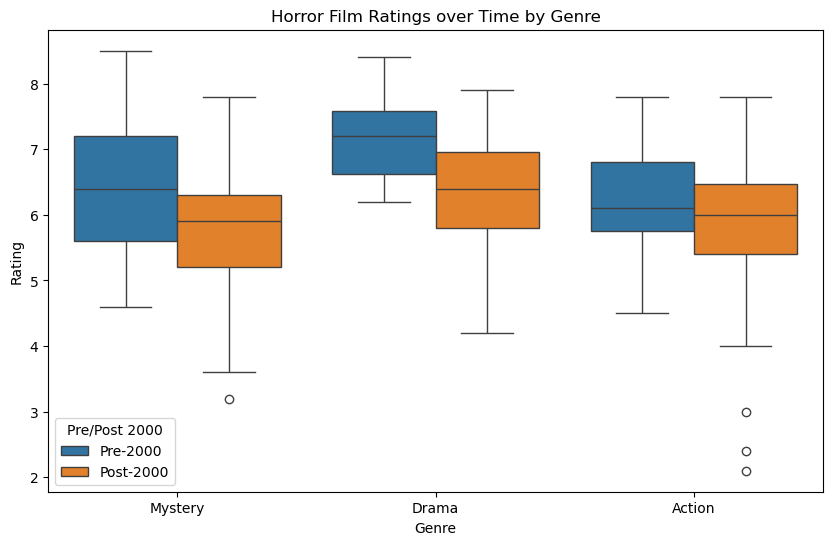

In [410]:
plt.figure(figsize=(10,6))
sns.boxplot(data=top_horror, x='Genre_clean',y='Rating', hue='Pre/Post 2000')
plt.xlabel('Genre')
plt.title('Horror Film Ratings over Time by Genre')
plt.show()

## Section 3

Read in the `haunted_places` dataset. This is a dataset of all known haunting in the U.S. and associated descriptions. Each record is associated with one haunting. 

In [411]:
hauntings = pd.read_csv("./data/haunted_places.csv")
hauntings.head()

,city,country,description,location,state,state_abbrev,longitude,latitude,city_longitude,city_latitude
0,Ada,United States,Ada witch - Sometimes you can see a misty blue...,Ada Cemetery,Michigan,MI,-85.504893,42.962106,-85.495480,42.960727
1,Addison,United States,A little girl was killed suddenly while waitin...,North Adams Rd.,Michigan,MI,-84.381843,41.971425,-84.347168,41.986434
2,Adrian,United States,If you take Gorman Rd. west towards Sand Creek...,Ghost Trestle,Michigan,MI,-84.035656,41.904538,-84.037166,41.897547
3,Adrian,United States,"In the 1970's, one room, room 211, in the old ...",Siena Heights University,Michigan,MI,-84.017565,41.905712,-84.037166,41.897547
4,Albion,United States,Kappa Delta Sorority - The Kappa Delta Sororit...,Albion College,Michigan,MI,-84.745177,42.244006,-84.753030,42.243097


#### Question 1

Read in the `state_populations` file and use it (with `haunted_places`) to determine which state has the most hauntings *per capita* in the United States (hauntings per individual). Return your answer as a string. 

In [412]:
pop = pd.read_csv("./data/state_populations.csv")

In [413]:
haunting_grouped = hauntings.groupby('state').count()
haunting_merged = pd.merge(haunting_grouped, pop, on='state', how='left')
haunting_merged['per_capita'] = haunting_merged['city'] / haunting_merged['population']
haunting_merged.sort_values('per_capita')

most_haunted = haunting_merged.iloc[0,0]
most_haunted

'Alabama'

In [414]:
grader.check("q3_1")

q3_1 results: All test cases passed!

#### Question 2

The ratios of females to males in the U.S. is roughly 49/51 (or about 0.96). One would presume that hauntings reflect a similar sex ratio. 

What ratio of hauntings involve a girl versus a boy ($\frac{girl}{boy}$) and what ratio involve a woman versus a man ($\frac{woman}{man}$)?

In [415]:
hauntings['desciption'] = hauntings['description'].fillna('')
hauntings['girl'] = hauntings['description'].str.contains(r'\bgirl\b', case = False, na = False)
hauntings['boy'] = hauntings['description'].str.contains(r'\bboy\b', case = False, na = False)
hauntings['woman'] = hauntings['description'].str.contains(r'\bwoman\b', case = False, na = False)
hauntings['man'] = hauntings['description'].str.contains(r'\bman\b', case = False, na = False)

girl_count = hauntings['girl'].sum()
boy_count = hauntings['boy'].sum()
woman_count = hauntings['woman'].sum()
man_count = hauntings['man'].sum()
man_count

1613

In [416]:
girl_boy_ratio = girl_count/boy_count if boy_count > 0 else 0.0
print(girl_boy_ratio)
woman_man_ratio = woman_count/man_count if man_count > 0 else 0.0
woman_man_ratio

2.0955631399317407


0.7396156230626162

In [417]:
grader.check("q3_2")

q3_2 results: All test cases passed!

Is the ratio similar or different between the two subsets? What can we infer about how age affects the likelihood of different sexes lingering after death?

**Your response** The girl/boy ratio and the woman/man ratio are different. Since the equation is female over male girl_boy_ratio is ~2.10, meanig there are more girl hauntings in comparison to boy haunting. On the contrary, in woman_man_ratio we get the result ~0.7, meaning there is a hirgher # of man hauntings that woman hauntings. We can then infer that the age of the group involved in a haunting influences the potential gender of the ghost/entity. In other words, when children are involved with the haunting there is a higher chance that the ghost or entity is a girl and if it were between a man or a woman the haunting would be done by a man.

#### Question 3

Create a horizontal barplot of the 20 most common locations in the haunting descriptions. Be sure to lowercase all of the words. The resulting barchart should *only* include general location names (e.g. hospital, cemetary, house), not proper nouns (e.g. the specific name of a hospital), articles (e.g "the", "an", "is" etc...) or adjectives. Multiple words for the same thing is ok (e.g. street and road).

In [418]:
# Lowercase the location names & extract words from 'location' with Regex
locations = hauntings['location'].dropna().str.lower()
words = locations.str.findall(r'\b[a-z]{3,}\b').explode()

# Define a small list of stopwords and common non-location words to exclude & filter out (Generated by Gemini)
stopwords = set([
    'the', 'and', 'for', 'from', 'that', 'this', 'was', 'are', 'have', 'had',
    'but', 'not', 'his', 'her', 'she', 'who', 'its', 'our', 'out', 'where',
    'there', 'they', 'been', 'into', 'about', 'when', 'their', 'over', 'after',
    'then', 'one', 'two', 'very', 'some', 'more', 'most', 'many', 'much',
    'such', 'also', 'other', 'like', 'than', 'just', 'only', 'even', 'ever',
    'every', 'being', 'those', 'these', 'which', 'what', 'why', 'how', 'can',
    'could', 'would', 'should', 'might', 'before', 'behind', 'under', 'above',
    'near', 'across', 'toward', 'towards', 'another', 'each', 'same', 'own',
    'small', 'large', 'great', 'old', 'new', 'haunted', 'haunting', 'ghost'
])
filtered_words = words[~words.isin(stopwords)]

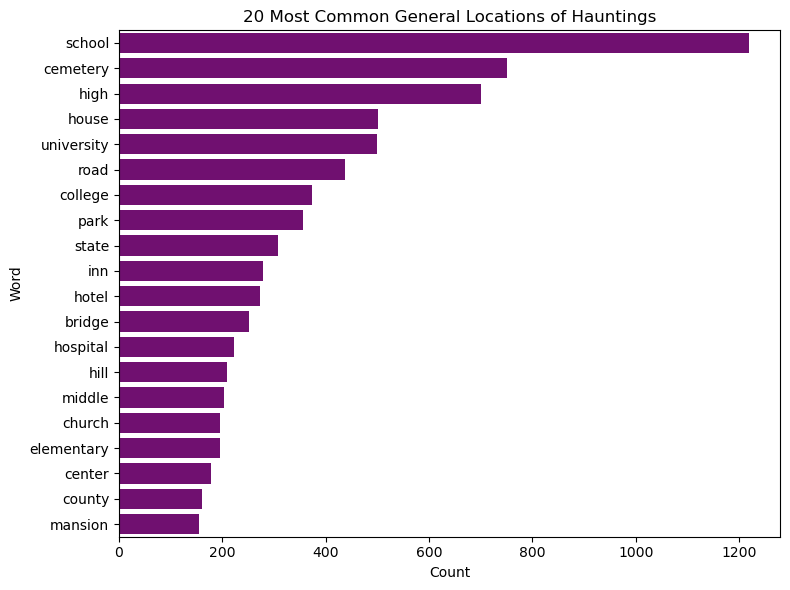

In [419]:
# Count, take top 20
word_counts = filtered_words.value_counts()
top20 = word_counts.iloc[:20]

# Plot
plt.figure(figsize=(8,6))
sns.barplot(top20.sort_values(ascending=False), orient='h', color='purple')
plt.title('20 Most Common General Locations of Hauntings')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

Why do you suppose some of these places are more haunted than others?

**Your response**: The most frequent haunting reports originate from locations with deep emotional or historical ties. Cemeteries are intrinsically linked to death, while schools and universities often possess long, storied pasts within their communities. Houses and mansions, as personal spaces, make tragedies or deaths feel more intimate, and roads or bridges are commonly associated with accidents and urban legends. In essence, hauntings seem to cluster in places defined by intense human experiences or where memorable stories can easily form and circulate.

#### Question 4

In your opinion, what is the scariest haunting in Eugene?

In [420]:
print(hauntings.iloc[2210]["description"])
hauntings.query('city == "Eugene" and state == "Oregon"')


In the courtyard there have been several sightings of a women dressed in white calling for her daughter "Francis". Often do bushes and trees move when she gets mad that she can't find her.


,city,country,description,location,state,state_abbrev,longitude,latitude,city_longitude,city_latitude,desciption,girl,boy,woman,man
2206,Eugene,United States,February 2007 correction: Formerly listed as F...,Fox Hallow French Immersion School,Oregon,OR,-123.075330,44.013436,-123.086754,44.052069,February 2007 correction: Formerly listed as F...,False,False,False,False
2207,Eugene,United States,"Reports of a weird presence, lights turn on an...",French Immersion School,Oregon,OR,-123.075330,44.013436,-123.086754,44.052069,"Reports of a weird presence, lights turn on an...",False,False,False,True
2208,Eugene,United States,Janitors working over night tell stories of do...,Kmart,Oregon,OR,-123.252295,44.586809,-123.086754,44.052069,Janitors working over night tell stories of do...,False,False,False,False
2209,Eugene,United States,The elevator in the center building is haunted...,Lane Community College,Oregon,OR,-123.034682,44.009040,-123.086754,44.052069,The elevator in the center building is haunted...,False,False,False,False
2210,Eugene,United States,In the courtyard there have been several sight...,Sheldon High school,Oregon,OR,-123.071911,44.082083,-123.086754,44.052069,In the courtyard there have been several sight...,False,False,False,False
2211,Eugene,United States,A Student was in the high school auditorium. H...,South Eugene High school,Oregon,OR,-123.086691,44.037770,-123.086754,44.052069,A Student was in the high school auditorium. H...,False,False,False,False
2212,Eugene,United States,In the back room the upstairs is haunted by so...,Toys R Us,Oregon,OR,-123.105229,44.073028,-123.086754,44.052069,In the back room the upstairs is haunted by so...,False,False,False,False
2213,Eugene,United States,Stafford Hall - Outside of room 101 of the Sta...,University of Oregon,Oregon,OR,-123.072605,44.044830,-123.086754,44.052069,Stafford Hall - Outside of room 101 of the Sta...,False,False,False,False
2214,Eugene,United States,A young boy was shot on the playground. And wh...,Woodland Park,Oregon,OR,-123.183828,44.081179,-123.086754,44.052069,A young boy was shot on the playground. And wh...,False,True,False,False


**Your response**: I think the scariest haunting is the woman calling for her daughter - hearing that at school late at night would be very scary.

# Submission

**That's a wrap!** I hope this exam didn't jump scare you.

Be sure to check that all of your tests pass the autograder.

In [421]:
grader.check_all()

q1_1 results: All test cases passed!

q1_2 results: All test cases passed!

q1_3 results: All test cases passed!

q1_4 results: All test cases passed!

q2_2 results: All test cases passed!

q2_6 results: All test cases passed!

q2_8 results: All test cases passed!

q2_9 results: All test cases passed!

q3_1 results: All test cases passed!

q3_2 results: All test cases passed!

Make sure you have run all cells in your notebook in order. Then execute the following in the File menu

* Save and Checkpoint
* Close and Halt

Then upload your notebook to Canvas Assignment Midterm.